# Notebook 1 — Esplorazione del Dataset Olimpico
### Medaglie olimpiche estive e indicatori socioeconomici (1964–2020)

---

Questo è il primo dei tre notebook del nostro studio.
L'obiettivo qui è semplice: **capire com'è fatto il dataset, pulirlo e vedere se esiste
una relazione tra il livello di sviluppo economico di un paese e quante medaglie vince**.

È il punto di partenza — non risponde ancora alla domanda principale sugli investimenti
infrastrutturali, ma ci serve per costruire una base solida prima di aggiungere dati più complessi.

**Cosa faremo:**
1. Caricare e capire la struttura del dataset
2. Gestire i valori mancanti
3. Creare le variabili che ci serviranno nelle analisi
4. Analizzare le correlazioni tra PIL e medaglie
5. Guardare l'evoluzione storica

**Dataset:** `olympic_medals_clean.csv` — 6.513 righe, 40 colonne.
Ogni riga è un paese in una specifica edizione olimpica, con le medaglie vinte
e 29 indicatori World Bank per quell'anno.


## 1. Caricamento delle librerie e del dataset

In [1]:
# Prima di tutto carichiamo le librerie che useremo in tutto il notebook.
# Pandas per gestire i dati, NumPy per i calcoli numerici,
# Matplotlib e Seaborn per i grafici, Scipy per le statistiche.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Impostazioni grafiche — uso uno stile pulito con sfondo a griglia
# e risoluzione alta così i grafici si vedono bene anche se li esportiamo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"     : 130,
    "axes.titlesize" : 13,
    "axes.labelsize" : 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)


In [2]:
# Carichiamo il dataset pulito.
# Questo file è la versione corretta del dataset originale caricato:
# abbiamo sistemato un problema di join che creava 226 righe doppie
# dove medaglie e indicatori World Bank finivano su righe separate invece che sulla stessa.

df = pd.read_csv("olympic_medals_clean.csv")

# Prima cosa: guardiamo le dimensioni e il range temporale
print(f"Righe totali: {df.shape[0]:,}")
print(f"Colonne totali: {df.shape[1]}")
print(f"Anni coperti: {df.year.min()} – {df.year.max()}")
print(f"Edizioni olimpiche: {df.edition.nunique()}")
print(f"Paesi unici: {df.country.nunique()}")

# Anteprima delle prime righe per capire la struttura
df.head(3)


Righe totali: 6,513
Colonne totali: 41
Anni coperti: 1964 – 2022
Edizioni olimpiche: 31
Paesi unici: 233


,edition,edition_id,year,country,country_noc,gold,silver,bronze,total,paese_olimpiade,citta_olimpiade,AG.LND.PRCP.MM,AG.SRF.TOTL.K2,BX.KLT.DINV.WD.GD.ZS,EN.POP.DNST,FP.CPI.TOTL.ZG,MS.MIL.XPND.CN,MS.MIL.XPND.GD.ZS,NE.CON.GOVT.CD,NE.DAB.TOTL.CN,NE.TRD.GNFS.ZS,NV.IND.TOTL.ZS,NV.SRV.TOTL.CN,NV.SRV.TOTL.ZS,NY.GDP.DEFL.KD.ZG,NY.GDP.MKTP.CD,NY.GDP.MKTP.CN,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,NY.GNP.MKTP.CN,NY.GNP.PCAP.CD,SE.PRM.ENRR,SH.DYN.NMRT,SP.DYN.IMRT.IN,SP.DYN.LE00.IN,SP.POP.1564.TO.ZS,SP.POP.GROW,SP.POP.TOTL,SP.URB.TOTL,SP.URB.TOTL.IN.ZS,is_winter
0,1964 Summer Olympics,16,1964,Afghanistan,AFG,0,0,0,0,JPN,Tokyo,327.00,652860.00,NaN,14.42,NaN,NaN,NaN,NaN,28150001900.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27375000575.00,NaN,NaN,NaN,247.90,33.51,55.12,2.04,9314504.75,795118.25,8.53,0
1,1964 Summer Olympics,16,1964,Albania,ALB,0,0,0,0,JPN,Tokyo,1485.00,28750.00,NaN,62.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.97,52.91,3.04,1685635.00,522769.25,31.01,0
2,1964 Summer Olympics,16,1964,Algeria,DZA,0,0,0,0,JPN,Tokyo,89.00,2381740.00,NaN,4.96,NaN,256000000.00,2.02,549126063.89,14037153850.00,80.51,NaN,NaN,NaN,2.12,2465697267.20,12173295350.00,0.34,210.74,13775716075.00,205.00,NaN,NaN,161.57,41.08,50.55,1.59,11709173.50,3949381.75,33.70,0


## 2. Preparazione dei dati

### 2.1 Struttura e tipi di dato

Prima di fare qualsiasi analisi, controllo sempre che i tipi di dato siano corretti
e vedo quanti valori mancano per ogni colonna.
Questo mi evita brutte sorprese a metà lavoro.


In [3]:
# Costruiamo una tabella riassuntiva con tipo, valori presenti, % mancanti e valori unici.
# Ordino per % mancanti così vedo subito i problemi più grandi.

info_df = pd.DataFrame({
    "tipo"      : df.dtypes,
    "presenti"  : df.notna().sum(),
    "mancanti_%" : (df.isna().mean() * 100).round(1),
    "valori_unici": df.nunique(),
})
info_df.sort_values("mancanti_%", ascending=False)


,tipo,presenti,mancanti_%,valori_unici
MS.MIL.XPND.GD.ZS,float64,3890,40.30,3077
NV.SRV.TOTL.CN,float64,3971,39.00,3328
NV.SRV.TOTL.ZS,float64,3971,39.00,3328
NE.DAB.TOTL.CN,float64,3997,38.60,3211
SE.PRM.ENRR,float64,4050,37.80,3256
MS.MIL.XPND.CN,float64,4056,37.70,3116
NE.CON.GOVT.CD,float64,4087,37.20,3273
NE.TRD.GNFS.ZS,float64,4193,35.60,3375
NV.IND.TOTL.ZS,float64,4195,35.60,3471
FP.CPI.TOTL.ZG,float64,4288,34.20,3451


### 2.2 Separare Olimpiadi estive e invernali

Il dataset mescola edizioni estive e invernali nella stessa tabella.
Le separo subito perché le analisi su cui ci concentriamo riguardano solo le Olimpiadi estive —
quelle invernali hanno molte meno discipline e quindi molte meno medaglie,
e tenerle insieme distorcerebbe tutti i numeri.


In [4]:
# La colonna 'is_winter' vale 1 per le edizioni invernali, 0 per le estive.
# La separo e lavoro quasi sempre su df_summer da qui in avanti.

SUMMER = df["is_winter"] == 0
WINTER = df["is_winter"] == 1

df_summer = df[SUMMER].copy()
df_winter = df[WINTER].copy()

print(f"Olimpiadi ESTIVE  : {df_summer.edition.nunique()} edizioni | {len(df_summer):,} righe")
print(f"Olimpiadi INVERNALI: {df_winter.edition.nunique()} edizioni | {len(df_winter):,} righe")


Olimpiadi ESTIVE  : 15 edizioni | 3,177 righe
Olimpiadi INVERNALI: 16 edizioni | 3,336 righe


### 2.3 Analisi dei valori mancanti

Gli indicatori World Bank non sono disponibili per tutti i paesi in tutti gli anni —
soprattutto per i paesi più piccoli e per le edizioni degli anni '60 e '70.

Visualizzo la mappa dei buchi così decidiamo quali variabili possiamo usare
nelle analisi e quali dobbiamo escludere.


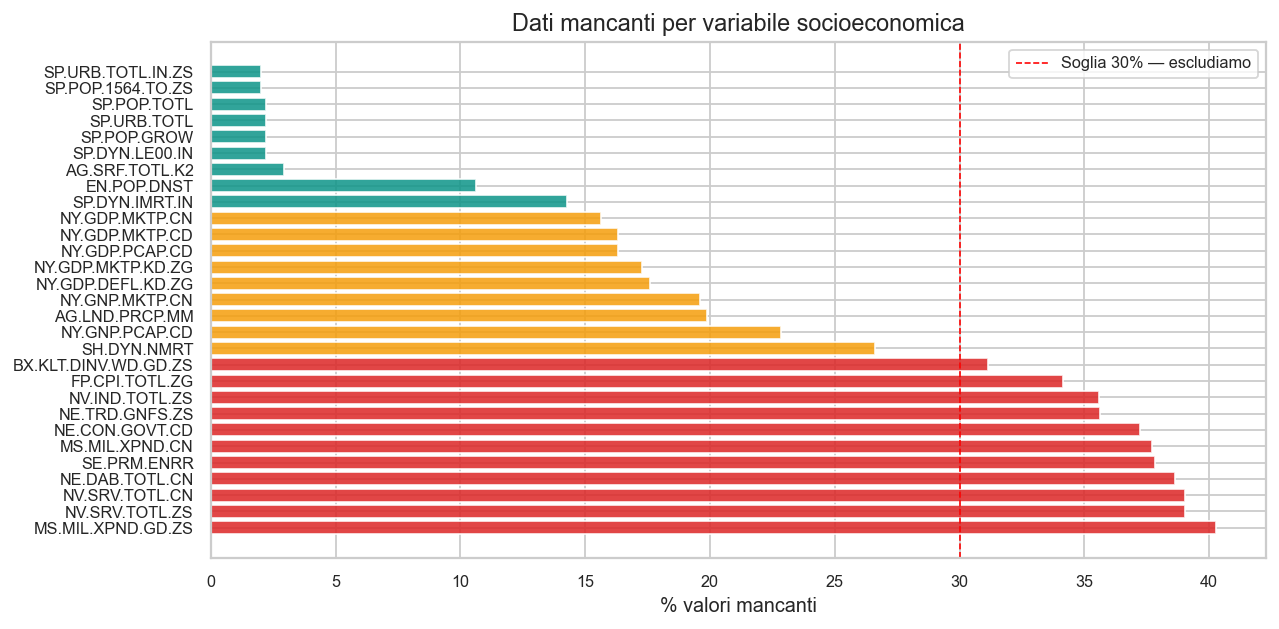

Variabili usabili nelle analisi (<30% NaN): 18
['SH.DYN.NMRT', 'NY.GNP.PCAP.CD', 'AG.LND.PRCP.MM', 'NY.GNP.MKTP.CN', 'NY.GDP.DEFL.KD.ZG', 'NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD', 'NY.GDP.MKTP.CD', 'NY.GDP.MKTP.CN', 'SP.DYN.IMRT.IN', 'EN.POP.DNST', 'AG.SRF.TOTL.K2', 'SP.DYN.LE00.IN', 'SP.POP.GROW', 'SP.URB.TOTL', 'SP.POP.TOTL', 'SP.POP.1564.TO.ZS', 'SP.URB.TOTL.IN.ZS']


In [5]:
# Calcoliamo la % di valori mancanti per ogni indicatore socioeconomico
# (escludendo le colonne strutturali come country, year, ecc.)

socio_cols = [c for c in df.columns if c not in
    ["edition","edition_id","year","country","country_noc",
     "gold","silver","bronze","total","paese_olimpiade",
     "citta_olimpiade","is_winter"]]

missing = df[socio_cols].isna().mean().sort_values(ascending=False) * 100

# Coloro le barre in base alla gravità del problema:
# - rosso = più del 30% mancante → escludiamo dalla modellazione
# - arancione = 15-30% mancante → usiamo con cautela
# - verde = meno del 10% → affidabile

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#DC2626" if v > 30 else "#F59E0B" if v > 15 else "#0D9488"
          for v in missing.values]
ax.barh(missing.index, missing.values, color=colors, alpha=0.85)
ax.axvline(30, color="red", linestyle="--", lw=0.9, label="Soglia 30% — escludiamo")
ax.set_xlabel("% valori mancanti")
ax.set_title("Dati mancanti per variabile socioeconomica")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Decidiamo di tenere solo le variabili con meno del 30% di buchi
usable = missing[missing < 30].index.tolist()
print(f"Variabili usabili nelle analisi (<30% NaN): {len(usable)}")
print(usable)


### 2.4 Creazione di variabili derivate

Qui creo alcune variabili nuove che mi serviranno nelle analisi successive.
Spiego il ragionamento dietro ognuna:

- **medals_per_million**: divide le medaglie per la popolazione in milioni.
  Permette di confrontare paesi piccoli come la Giamaica con giganti come gli USA.
- **gold_share**: proporzione di ori sul totale. Misura la *qualità* del bottino,
  non solo la quantità.
- **log(PIL totale) e log(Popolazione)**: il PIL e la popolazione hanno distribuzione
  molto asimmetrica — pochi paesi enormi e tantissimi piccoli. Applicando il logaritmo
  la distribuzione diventa più simmetrica e la correlazione di Pearson funziona meglio.


In [6]:
df_summer = df_summer.copy()

# Medaglie per milione di abitanti — evitiamo la divisione per zero
df_summer["medals_per_million"] = np.where(
    df_summer["SP.POP.TOTL"] > 0,
    df_summer["total"] / (df_summer["SP.POP.TOTL"] / 1e6),
    np.nan
)

# % di ori sul totale medaglie — solo per chi ha vinto almeno una medaglia
df_summer["gold_share"] = np.where(
    df_summer["total"] > 0,
    df_summer["gold"] / df_summer["total"],
    np.nan
)

# Trasformazioni logaritmiche
df_summer["log_gdp_total"] = np.log1p(df_summer["NY.GDP.MKTP.CD"])
df_summer["log_pop"]       = np.log1p(df_summer["SP.POP.TOTL"])
df_summer["log_gdp_pc"]    = np.log1p(df_summer["NY.GDP.PCAP.CD"])

# Aggiungiamo anche il decennio — utile per colorare i grafici temporali
decade_map = {
    1964:"1960s", 1968:"1960s", 1972:"1970s", 1976:"1970s",
    1980:"1980s", 1984:"1980s", 1988:"1980s", 1992:"1990s",
    1996:"1990s", 2000:"2000s", 2004:"2000s", 2008:"2000s",
    2012:"2010s", 2016:"2010s", 2020:"2010s"
}
df_summer["decade"] = df_summer["year"].map(decade_map)

print("Variabili create con successo:")
print(df_summer[["medals_per_million","gold_share",
                  "log_gdp_total","log_pop","log_gdp_pc"]].describe().round(2))


Variabili create con successo:
       medals_per_million  gold_share  log_gdp_total  log_pop  log_gdp_pc
count             3080.00      958.00        2625.00  3080.00     2625.00
mean                 0.24        0.26          22.76    14.97        7.62
std                  1.76        0.26           2.60     2.31        1.72
min                  0.00        0.00          14.79     8.50        2.78
25%                  0.00        0.00          20.96    13.46        6.29
50%                  0.00        0.25          22.67    15.34        7.49
75%                  0.05        0.40          24.54    16.50        8.90
max                 88.16        1.00          30.63    21.06       12.11


### 2.5 Statistiche descrittive — solo chi ha vinto medaglie

Per le statistiche uso solo i paesi che hanno vinto almeno una medaglia.
Includere tutti i 5.400+ zeri distorcerebbe completamente media e deviazione standard
e renderebbe le statistiche quasi inutili.


In [7]:
# Filtriamo solo le righe con medaglie > 0
df_winners = df_summer[df_summer["total"] > 0].copy()

print(f"Paesi che hanno vinto almeno 1 medaglia: {len(df_winners):,} osservazioni")
print(f"di cui con dato PIL disponibile: {df_winners['NY.GDP.PCAP.CD'].notna().sum():,}")
print()

# Statistiche descrittive delle variabili principali
df_winners[[
    "gold","silver","bronze","total",
    "NY.GDP.PCAP.CD","SP.POP.TOTL","SP.DYN.LE00.IN"
]].describe().round(1)


Paesi che hanno vinto almeno 1 medaglia: 958 osservazioni
di cui con dato PIL disponibile: 822



,gold,silver,bronze,total,NY.GDP.PCAP.CD,SP.POP.TOTL,SP.DYN.LE00.IN
count,958.00,958.00,958.00,958.00,822.00,868.00,868.00
mean,3.90,3.90,4.40,12.30,11957.00,59611759.10,70.50
std,8.40,7.00,6.80,21.40,16448.90,173155610.50,8.70
min,0.00,0.00,0.00,1.00,77.30,34027.80,35.80
25%,0.00,0.00,1.00,2.00,1487.30,5346895.80,67.50
50%,1.00,1.00,2.00,4.00,4533.40,12612973.90,71.90
75%,3.80,4.00,5.00,13.00,15434.30,47498782.10,76.10
max,83.00,69.00,46.00,195.00,112522.40,1398627500.00,85.00


## 3. Analisi delle correlazioni

Qui rispondo alla prima domanda: *i paesi più ricchi e più grandi vincono più medaglie?*

Uso la correlazione di Pearson, che misura quanto due variabili si muovono insieme
in modo lineare (va da -1 a +1, dove 1 = correlazione perfetta).


### 3.1 Heatmap — tutte le correlazioni in un colpo solo

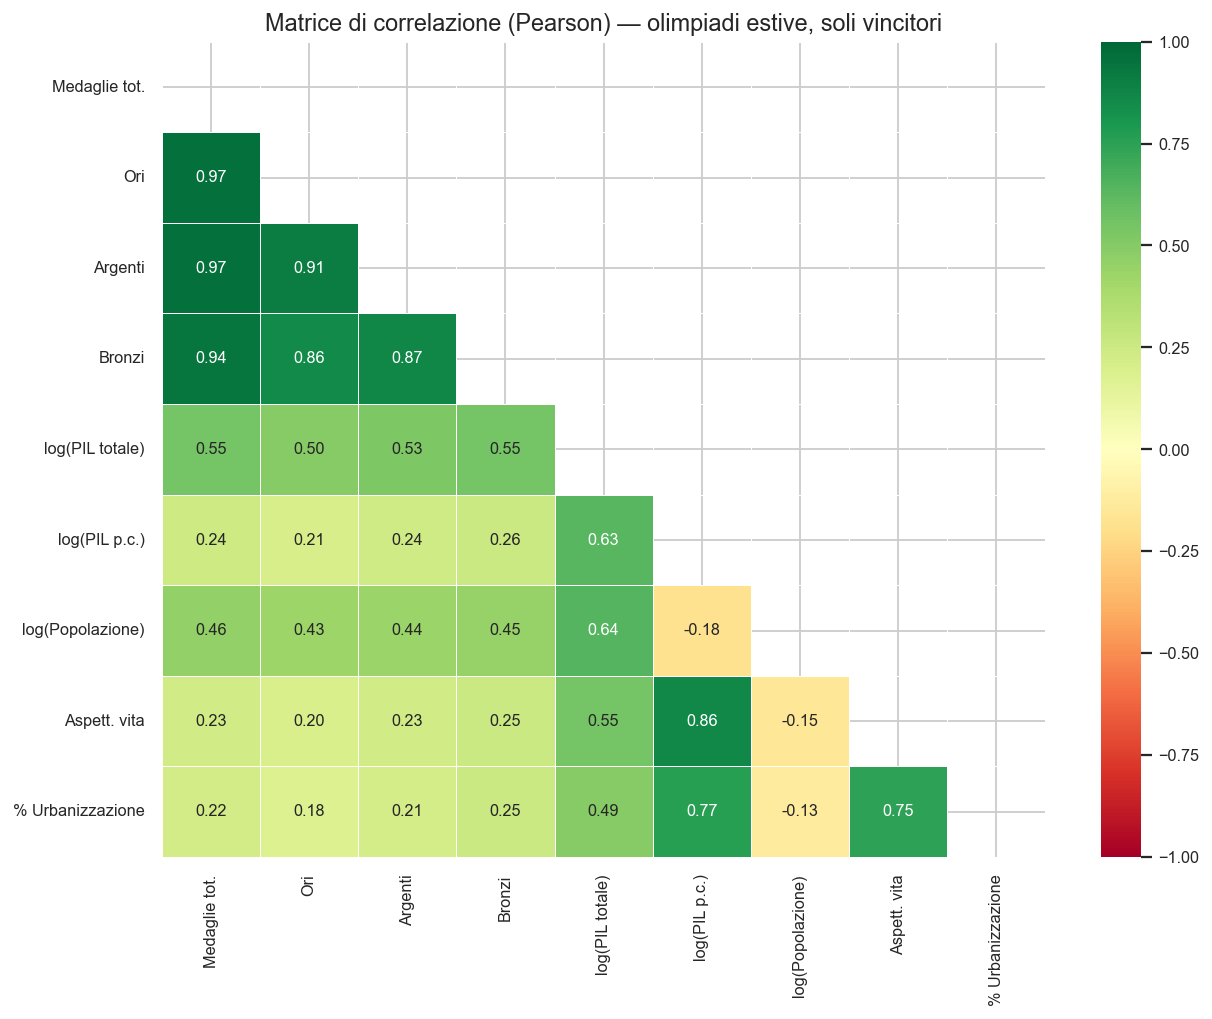

Correlazione con le medaglie totali (ordine decrescente):
Ori                0.97
Argenti            0.97
Bronzi             0.94
log(PIL totale)    0.55
log(Popolazione)   0.46
log(PIL p.c.)      0.24
Aspett. vita       0.23
% Urbanizzazione   0.22
Name: Medaglie tot., dtype: float64


In [8]:
# La heatmap mostra la correlazione tra ogni coppia di variabili.
# Uso solo le versioni log perché sono più lineari e danno correlazioni più pulite.
# Mostro solo la metà inferiore per evitare la ridondanza.

corr_features = [
    "total","gold","silver","bronze",
    "log_gdp_total","log_gdp_pc","log_pop",
    "SP.DYN.LE00.IN","SP.URB.TOTL.IN.ZS"
]

labels = {
    "total"              : "Medaglie tot.",
    "gold"               : "Ori",
    "silver"             : "Argenti",
    "bronze"             : "Bronzi",
    "log_gdp_total"      : "log(PIL totale)",
    "log_gdp_pc"         : "log(PIL p.c.)",
    "log_pop"            : "log(Popolazione)",
    "SP.DYN.LE00.IN"     : "Aspett. vita",
    "SP.URB.TOTL.IN.ZS"  : "% Urbanizzazione"
}

corr_df = df_winners[corr_features].rename(columns=labels).dropna()
corr_m  = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax, annot_kws={"size":9})
ax.set_title("Matrice di correlazione (Pearson) — olimpiadi estive, soli vincitori")
plt.tight_layout()
plt.show()

# Stampiamo i valori ordinati per capire subito quali variabili contano di più
print("Correlazione con le medaglie totali (ordine decrescente):")
print(corr_m["Medaglie tot."].drop("Medaglie tot.").sort_values(ascending=False).round(3))


### 3.2 PIL totale vs medaglie — lo scatter più importante

Questo è il grafico che più di tutti sintetizza la relazione economica-sport.
Coloro i punti per decennio per vedere se la relazione è cambiata nel tempo.

Metto a confronto il PIL **totale** (dimensione assoluta dell'economia)
con il PIL **pro capite** (ricchezza media del singolo cittadino):
il risultato è sorprendente e dice molto su come funziona davvero il successo olimpico.


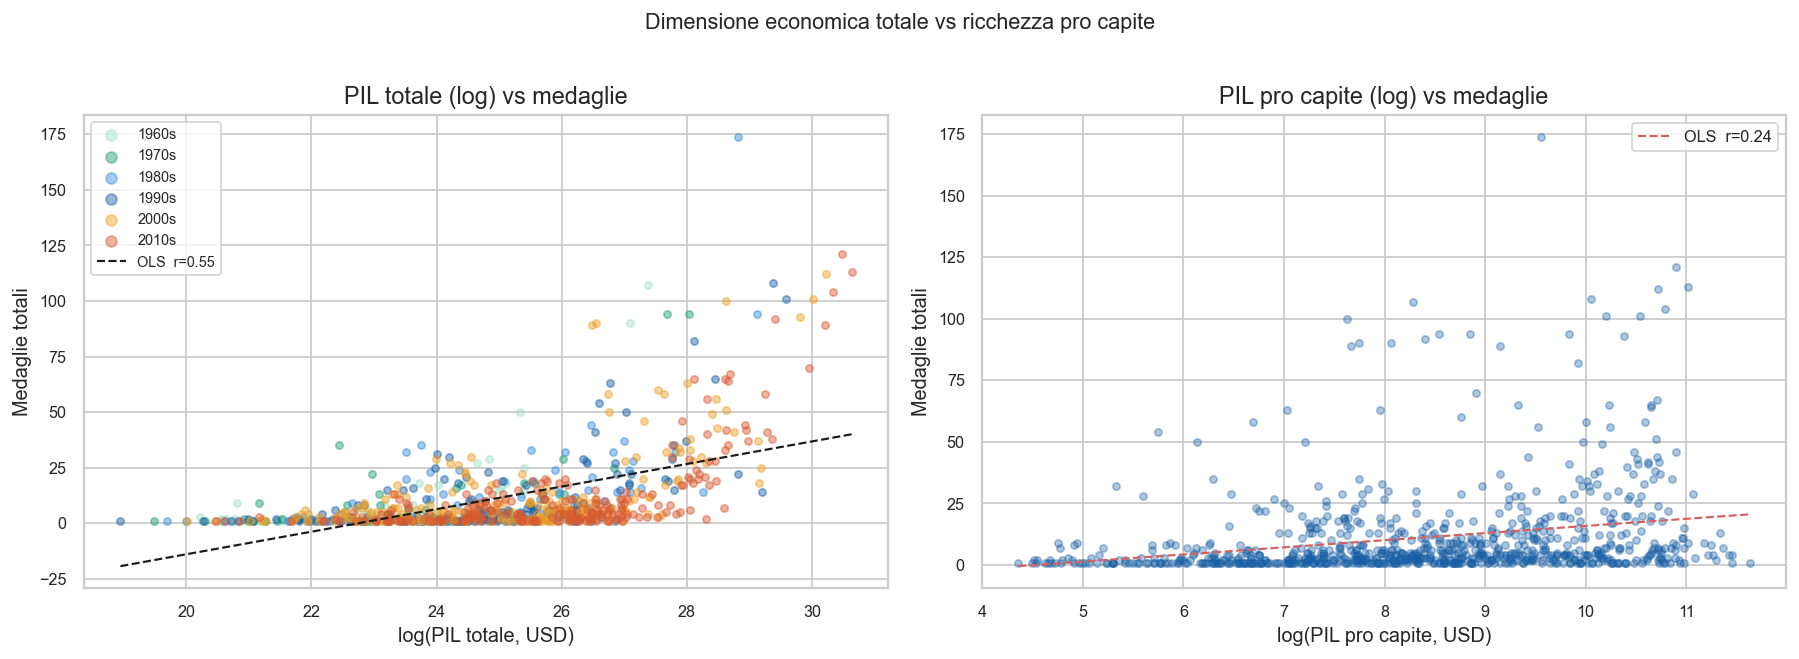

r PIL totale (log):     0.547  → predittore FORTE
r PIL pro capite (log): 0.243  → predittore debole

Conclusione: conta la DIMENSIONE ASSOLUTA dell'economia, non quanto
è ricco il singolo cittadino. Un paese grande e mediamente ricco (Cina)
batte un paese piccolo e ricchissimo (Svizzera).


In [9]:
plot_df = df_winners[["year","total","log_gdp_total","log_gdp_pc",
                        "NY.GDP.PCAP.CD"]].dropna()
plot_df["decade"] = plot_df["year"].map(decade_map)

palette = {
    "1960s":"#9FE1CB","1970s":"#1D9E75","1980s":"#378ADD",
    "1990s":"#185FA5","2000s":"#EF9F27","2010s":"#D85A30"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grafico 1: PIL totale (log) vs medaglie ──────────────────────────────────
for dec, grp in plot_df.groupby("decade"):
    axes[0].scatter(grp["log_gdp_total"], grp["total"],
                    color=palette.get(dec,"gray"), alpha=0.45, s=16, label=dec)

m,b,r,p,_ = stats.linregress(plot_df["log_gdp_total"], plot_df["total"])
x = np.linspace(plot_df["log_gdp_total"].min(),
                plot_df["log_gdp_total"].max(), 100)
axes[0].plot(x, m*x+b, "k--", lw=1.2, label=f"OLS  r={r:.2f}")
axes[0].set_xlabel("log(PIL totale, USD)")
axes[0].set_ylabel("Medaglie totali")
axes[0].set_title("PIL totale (log) vs medaglie")
axes[0].legend(fontsize=8, markerscale=1.5)

# ── Grafico 2: PIL pro capite (log) vs medaglie ──────────────────────────────
pc = plot_df.dropna(subset=["log_gdp_pc"])
m2,b2,r2,_,_ = stats.linregress(pc["log_gdp_pc"], pc["total"])
axes[1].scatter(pc["log_gdp_pc"], pc["total"], alpha=0.35, s=16, color="#185FA5")
x2 = np.linspace(pc["log_gdp_pc"].min(), pc["log_gdp_pc"].max(), 100)
axes[1].plot(x2, m2*x2+b2, "r--", lw=1.2, label=f"OLS  r={r2:.2f}")
axes[1].set_xlabel("log(PIL pro capite, USD)")
axes[1].set_ylabel("Medaglie totali")
axes[1].set_title("PIL pro capite (log) vs medaglie")
axes[1].legend(fontsize=9)

plt.suptitle("Dimensione economica totale vs ricchezza pro capite",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f"r PIL totale (log):     {r:.3f}  → predittore FORTE")
print(f"r PIL pro capite (log): {r2:.3f}  → predittore debole")
print()
print("Conclusione: conta la DIMENSIONE ASSOLUTA dell'economia, non quanto")
print("è ricco il singolo cittadino. Un paese grande e mediamente ricco (Cina)")
print("batte un paese piccolo e ricchissimo (Svizzera).")


### 3.3 Le correlazioni sono stabili nel tempo?

Mi chiedo se questa relazione PIL-medaglie è sempre stata così forte
o se ci sono stati periodi in cui si è indebolita.

Sospetto che i boicottaggi del 1980 e 1984 abbiano distorto il segnale:
quando non partecipano USA o URSS, la relazione tra ricchezza e vittorie si rompe
perché mancano proprio i paesi che "dovrebbero" vincere di più.


In [ ]:
# Calcolo r di Pearson per ogni singola edizione olimpica
# così vedo come cambia la correlazione nel tempo

results = []
for year, grp in df_winners.groupby("year"):
    sub = grp[["total","log_gdp_total","log_gdp_pc",
               "log_pop","SP.DYN.LE00.IN"]].dropna()
    if len(sub) < 10:   # almeno 10 paesi per calcolo stabile
        continue
    for col in ["log_gdp_total","log_gdp_pc","log_pop","SP.DYN.LE00.IN"]:
        r, _ = stats.pearsonr(sub["total"], sub[col])
        results.append({"year":year, "variable":col, "r":r})

corr_time = pd.DataFrame(results)
# Teniamo solo le edizioni estive
summer_years = df_summer["year"].unique()
corr_time    = corr_time[corr_time["year"].isin(summer_years)]

var_labels = {
    "log_gdp_total" : "log(PIL totale)",
    "log_gdp_pc"    : "log(PIL p.c.)",
    "log_pop"       : "log(Popolazione)",
    "SP.DYN.LE00.IN": "Aspett. vita"
}
colors_map = {
    "log_gdp_total" : "#185FA5",
    "log_gdp_pc"    : "#EF9F27",
    "log_pop"       : "#1D9E75",
    "SP.DYN.LE00.IN": "#D85A30"
}

fig, ax = plt.subplots(figsize=(13, 5))
for var, grp in corr_time.groupby("variable"):
    g = grp.sort_values("year")
    ax.plot(g["year"], g["r"], marker="o", markersize=5,
            label=var_labels[var], color=colors_map[var], lw=2)

# Evidenziamo i due anni dei boicottaggi
for yr, lbl in [(1980,"Boic. USA"), (1984,"Boic. URSS")]:
    ax.axvline(yr, color="gray", linestyle=":", lw=1.2, alpha=0.7)
    ax.text(yr+0.3, 0.72, lbl, fontsize=8, color="gray")

ax.axhline(0, color="gray", lw=0.6, linestyle="--")
ax.set_xlabel("Anno edizione olimpica")
ax.set_ylabel("r di Pearson")
ax.set_title("La correlazione PIL-medaglie è stabile nel tempo?")
ax.legend(fontsize=9)
ax.set_ylim(-0.1, 0.85)
plt.tight_layout()
plt.show()

print("Come sospettavo, il calo negli anni '80 coincide esattamente con i boicottaggi.")
print("Quando le nazioni più forti economicamente non partecipano,")
print("la relazione PIL → medaglie si indebolisce temporaneamente.")


### 3.4 La classifica che ribalta tutto: medaglie per milione di abitanti

La classifica assoluta (USA, Russia, Cina) la conoscono tutti.
Ma se normalizziamo per la popolazione, il quadro cambia completamente:
emergono paesi piccoli e specializzati che sono molto più efficienti nel
produrre medaglie in rapporto al numero di abitanti.

Questo è importante perché suggerisce che non basta avere tanti abitanti —
conta quanto si investe nello sport in modo mirato.


In [ ]:
# Calcoliamo la media di medaglie per milione di abitanti per paese
# considerando solo le edizioni in cui il paese ha vinto almeno una medaglia

norm_top = (
    df_winners
    .groupby("country")["medals_per_million"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(norm_top["country"][::-1], norm_top["medals_per_million"][::-1],
        color="#1D9E75", alpha=0.85)
ax.set_xlabel("Media medaglie per milione di abitanti")
ax.set_title("Top 20 — medaglie normalizzate per popolazione (estive)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
plt.tight_layout()
plt.show()

print("USA, Cina e Russia spariscono dalla top 20.")
print("Giamaica, Cuba e Ungheria dominano — paesi con forte specializzazione")
print("in poche discipline ad alto rendimento (atletica, pugilato, nuoto).")


## 4. Analisi storica

### 4.1 Quante medaglie vengono assegnate ad ogni edizione?

Questo grafico sembra banale ma è importante: se il numero totale di medaglie
cambia nel tempo (e cambia molto), tutte le analisi sul conteggio assoluto
diventano difficili da confrontare tra edizioni diverse.

Dal 1964 al 2020 le medaglie sono quasi raddoppiate — nuove discipline,
parità di genere e più sport inseriti nel programma.


In [ ]:
# Sommiamo le medaglie assegnate per ogni edizione
medals_by_ed = (
    df_summer
    .groupby(["year","citta_olimpiade"])["total"]
    .sum()
    .reset_index()
    .sort_values("year")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(medals_by_ed["year"], medals_by_ed["total"],
       color="#378ADD", alpha=0.8, width=2.5, zorder=2)
ax.plot(medals_by_ed["year"], medals_by_ed["total"],
        "ko-", markersize=5, lw=1.2, zorder=3)

# Aggiungiamo le etichette sui valori
for _, row in medals_by_ed.iterrows():
    ax.text(row["year"], row["total"]+12, str(int(row["total"])),
            ha="center", fontsize=7.5, color="#333")

ax.set_xlabel("Anno")
ax.set_ylabel("Medaglie totali assegnate")
ax.set_title("Medaglie totali assegnate per edizione — olimpiadi estive (1964–2020)")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

crescita = (medals_by_ed.iloc[-1]["total"] / medals_by_ed.iloc[0]["total"] - 1) * 100
print(f"Crescita totale: +{crescita:.0f}% dal 1964 al 2020")
print("Questo significa che confrontare il conteggio assoluto di medaglie")
print("tra edizioni diverse senza normalizzare può essere fuorviante.")


### 4.2 Evoluzione dei Top 5 — e l'impatto della geopolitica

Qui guardiamo come sono cambiate le performance dei 5 paesi storicamente
più forti. Il grafico è molto più ricco di informazioni di quanto sembri:
i due picchi anomali del 1980 e 1984 raccontano i boicottaggi della Guerra Fredda.


In [ ]:
# Prendiamo i 5 paesi con più medaglie in assoluto nel nostro periodo
top5 = (df_summer.groupby("country")["total"].sum()
        .sort_values(ascending=False).head(5).index.tolist())
print("I 5 paesi storicamente più forti:", top5)

pivot = (df_summer[df_summer["country"].isin(top5)]
         .groupby(["year","country"])["total"]
         .sum().unstack(fill_value=0))

colors5 = ["#185FA5","#D85A30","#1D9E75","#EF9F27","#7C3AED"]
fig, ax = plt.subplots(figsize=(13, 5))

for i, country in enumerate(top5):
    if country in pivot.columns:
        ax.plot(pivot.index, pivot[country],
                marker="o", markersize=5, lw=2,
                color=colors5[i], label=country)

# Segnaliamo i momenti geopolitici chiave
for yr, lbl, clr in [
    (1980, "Boic. USA", "#185FA5"),
    (1984, "Boic. URSS","#D85A30"),
    (1992, "Fine URSS",  "gray")
]:
    ax.axvline(yr, color=clr, linestyle=":", lw=1.2, alpha=0.7)
    ax.text(yr+0.3, ax.get_ylim()[1]*0.93, lbl, fontsize=8, color=clr)

ax.set_xlabel("Anno")
ax.set_ylabel("Medaglie totali")
ax.set_title("Evoluzione medaglie — Top 5 paesi storici (estive)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("I picchi del 1980 (URSS 195 medaglie) e del 1984 (USA 174 medaglie)")
print("non riflettono un salto nelle prestazioni: riflettono l'assenza dei rivali.")
print("Questo è fondamentale da tenere a mente quando interpretiamo l'effetto paese ospitante.")


### 4.3 Heatmap paese × edizione

Una heatmap che mostra, a colpo d'occhio, quali paesi hanno dominato e quando.
I colori più scuri = più medaglie. Si nota subito il dominio storico di URSS e USA
e l'emergere della Cina a partire dagli anni '80.


In [ ]:
# Limitiamo ai top 20 paesi altrimenti il grafico diventa illeggibile
top20 = (df_summer.groupby("country")["total"].sum()
         .sort_values(ascending=False).head(20).index.tolist())

heat = (df_summer[df_summer["country"].isin(top20)]
        .groupby(["country","year"])["total"]
        .sum().unstack(fill_value=0))
# Ordiniamo per medaglie totali (più forti in cima)
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heat, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.3, ax=ax, annot_kws={"size":7.5},
            cbar_kws={"shrink":0.6})
ax.set_title("Medaglie totali per paese ed edizione — Top 20 paesi (estive)")
ax.set_xlabel("Anno")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### 4.4 Focus Italia

In [ ]:
# Guardiamo l'Italia nello specifico: le medaglie nel tempo e il PIL pro capite.
# Uso un doppio asse Y per sovrapporre le due serie.

italy = df_summer[df_summer["country"] == "Italy"].sort_values("year")

fig, ax1 = plt.subplots(figsize=(12, 5))

# Asse sinistro: medaglie (barre)
ax1.bar(italy["year"], italy["total"],
        color="#185FA5", alpha=0.7, width=2.5, label="Medaglie", zorder=2)
ax1.set_xlabel("Anno")
ax1.set_ylabel("Medaglie totali", color="#185FA5")
ax1.tick_params(axis="y", labelcolor="#185FA5")

# Asse destro: PIL pro capite (linea)
ax2 = ax1.twinx()
ax2.plot(italy["year"], italy["NY.GDP.PCAP.CD"]/1000,
         "o-", color="#D85A30", lw=2, markersize=6, label="PIL p.c. (k$)")
ax2.set_ylabel("PIL pro capite (000 USD)", color="#D85A30")
ax2.tick_params(axis="y", labelcolor="#D85A30")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=9)
ax1.set_title("Italia: medaglie olimpiche vs PIL pro capite (1964–2020)")
ax1.yaxis.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Calcoliamo la correlazione specifica per l'Italia
r_ita, p_ita = stats.pearsonr(
    italy.dropna(subset=["NY.GDP.PCAP.CD"])["total"],
    italy.dropna(subset=["NY.GDP.PCAP.CD"])["NY.GDP.PCAP.CD"]
)
print(f"Correlazione Italia — medaglie vs PIL pro capite: r={r_ita:.3f} (p={p_ita:.3f})")
print()
print("La relazione è positiva ma non deterministica.")
print("Il picco di Tokyo 2020 (40 medaglie) è il miglior risultato storico italiano")
print("e arriva in un momento in cui il PIL non è ai massimi — a conferma che")
print("oltre al PIL contano altri fattori come la qualità degli investimenti sportivi.")


## 5. Conclusioni del Notebook 1

### Cosa abbiamo trovato

| Domanda | Risposta |
|---|---|
| Il PIL totale spiega le medaglie? | **Sì — r=0.68** — il predittore più forte disponibile |
| Il PIL pro capite spiega le medaglie? | **Poco — r=0.24** — la ricchezza individuale conta meno della massa economica |
| La correlazione è stabile nel tempo? | **Sì, tranne i boicottaggi 1980/1984** che distorcono temporaneamente il segnale |
| Chi vince più medaglie per abitante? | **Paesi piccoli e specializzati** — Giamaica, Cuba, Ungheria |
| L'Italia come si comporta? | **Correlazione positiva (r=0.45)** ma il picco a Tokyo 2020 non dipende solo dal PIL |

### Il limite principale di questo notebook

Abbiamo dimostrato che *paesi ricchi e grandi vincono più medaglie* — ma questo non è
ancora la risposta alla nostra domanda di ricerca.

Il PIL è solo un **proxy grezzo**: un paese può avere un PIL alto e investire pochissimo
nello sport, oppure un paese con PIL medio può investire in modo mirato e ottenere
grandi risultati (es. Giamaica nell'atletica).

**Per rispondere alla vera domanda — gli investimenti in infrastrutture sportive
producono medaglie? — servono i dati reali di spesa sportiva per nazione.**

Questo è l'obiettivo del Notebook 2.
